In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# einstein.png is in the main a1images folder
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [7]:
# load as grayscale — sharpening works on single channel
img = cv2.imread(os.path.join(IMG_DIR, 'einstein.png'), cv2.IMREAD_GRAYSCALE)

In [8]:
# unsharp mask: blur first, then add back the difference scaled by 1.5
# sigma=3 gives a broad enough blur so the edges actually pop
blurred = cv2.GaussianBlur(img, (0, 0), 3)
unsharp = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

In [9]:
# laplacian sharpening: convolve with the edge-detect kernel, then subtract from original
# kernel uses negative centre (+neighbours) so that img - lap gives f - ∇²f which sharpens
# float64 preserves the negative Laplacian values before the final clip
lap_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)
lap = cv2.filter2D(img.astype(np.float64), cv2.CV_64F, lap_kernel)
lap_sharp = np.clip(img.astype(np.float64) - lap, 0, 255).astype(np.uint8)


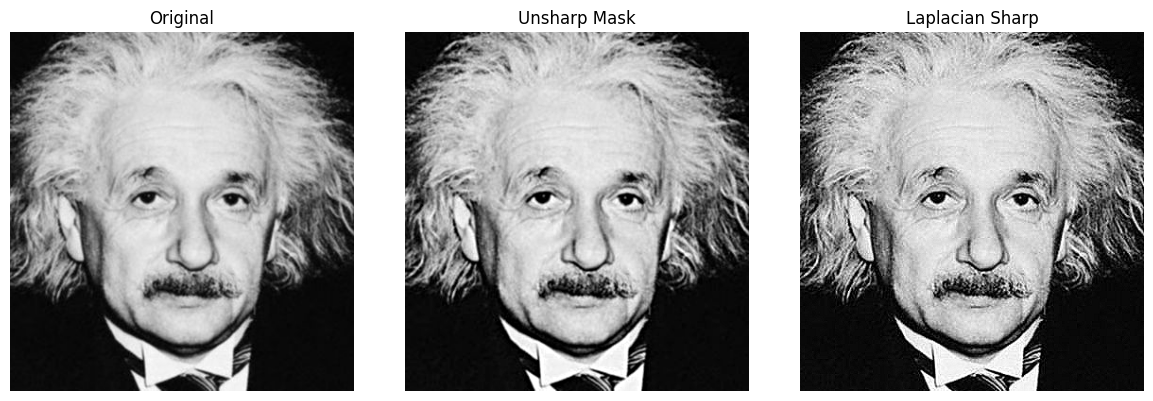

In [10]:
# compare all three so its clear how each method affects edge sharpness
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes,
                     [img, unsharp, lap_sharp],
                     ['Original', 'Unsharp Mask', 'Laplacian Sharp']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q9_sharpening.png'), dpi=150)
plt.show()